# Análise de Dados - Tênis de Corrida RunRepeat

## 6. Análise de Custo-Benefício

Análise focada em identificar os melhores tênis em termos de custo-benefício, relacionando preço com avaliação e outras características importantes para quem busca comprar um tênis de corrida.

In [15]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, HTML

sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

df = pd.read_csv('tenis_scraper_runrepeat/dados_finais/runrepeat_shoes_complete.csv')
print(f' Dataset carregado: {df.shape}')
print(f' Total de tênis: {len(df)}')

 Dataset carregado: (530, 46)
 Total de tênis: 530


## 6.1 Preparação dos Dados

Vamos criar métricas de custo-benefício combinando preço e avaliação.

In [16]:
# Filtrar apenas tênis com preço e avaliação válidos
df_analise = df[df['price_usd'].notna() & df['audience_score'].notna()].copy()

# Criar índice de custo-benefício (quanto maior, melhor)
# Score / Preço * 100 (para facilitar leitura)
df_analise['custo_beneficio'] = (df_analise['audience_score'] / df_analise['price_usd']) * 100

# Criar categorias de preço
df_analise['faixa_preco'] = pd.cut(df_analise['price_usd'], 
                                     bins=[0, 80, 120, 160, 300],
                                     labels=['Econômico (<$80)', 'Moderado ($80-120)', 
                                            'Premium ($120-160)', 'Top ($160+)'])

# Criar categorias de avaliação
df_analise['categoria_score'] = pd.cut(df_analise['audience_score'],
                                        bins=[0, 70, 80, 90, 100],
                                        labels=['Baixo (<70)', 'Médio (70-80)', 
                                               'Bom (80-90)', 'Excelente (90+)'])

print(f' Dados preparados: {len(df_analise)} tênis com preço e avaliação válidos')
print(f'\n Estatísticas do Índice de Custo-Benefício:')
print(df_analise['custo_beneficio'].describe())
print(f'\n O índice de custo-benefício = (Score / Preço) × 100')
print(f'   • Quanto MAIOR o índice, melhor a relação qualidade/preço')
print(f'   • Exemplo: Score 90, Preço $100 = C/B de 90.0')
print(f'   • Exemplo: Score 90, Preço $250 = C/B de 36.0')

 Dados preparados: 521 tênis com preço e avaliação válidos

 Estatísticas do Índice de Custo-Benefício:
count    521.000000
mean      61.592694
std       18.305493
min       27.666667
25%       51.176471
50%       58.666667
75%       66.923077
max      130.769231
Name: custo_beneficio, dtype: float64

 O índice de custo-benefício = (Score / Preço) × 100
   • Quanto MAIOR o índice, melhor a relação qualidade/preço
   • Exemplo: Score 90, Preço $100 = C/B de 90.0
   • Exemplo: Score 90, Preço $250 = C/B de 36.0


## 6.2 Relação Preço vs Avaliação

Visualização da relação entre preço e avaliação, destacando as zonas de melhor custo-benefício.

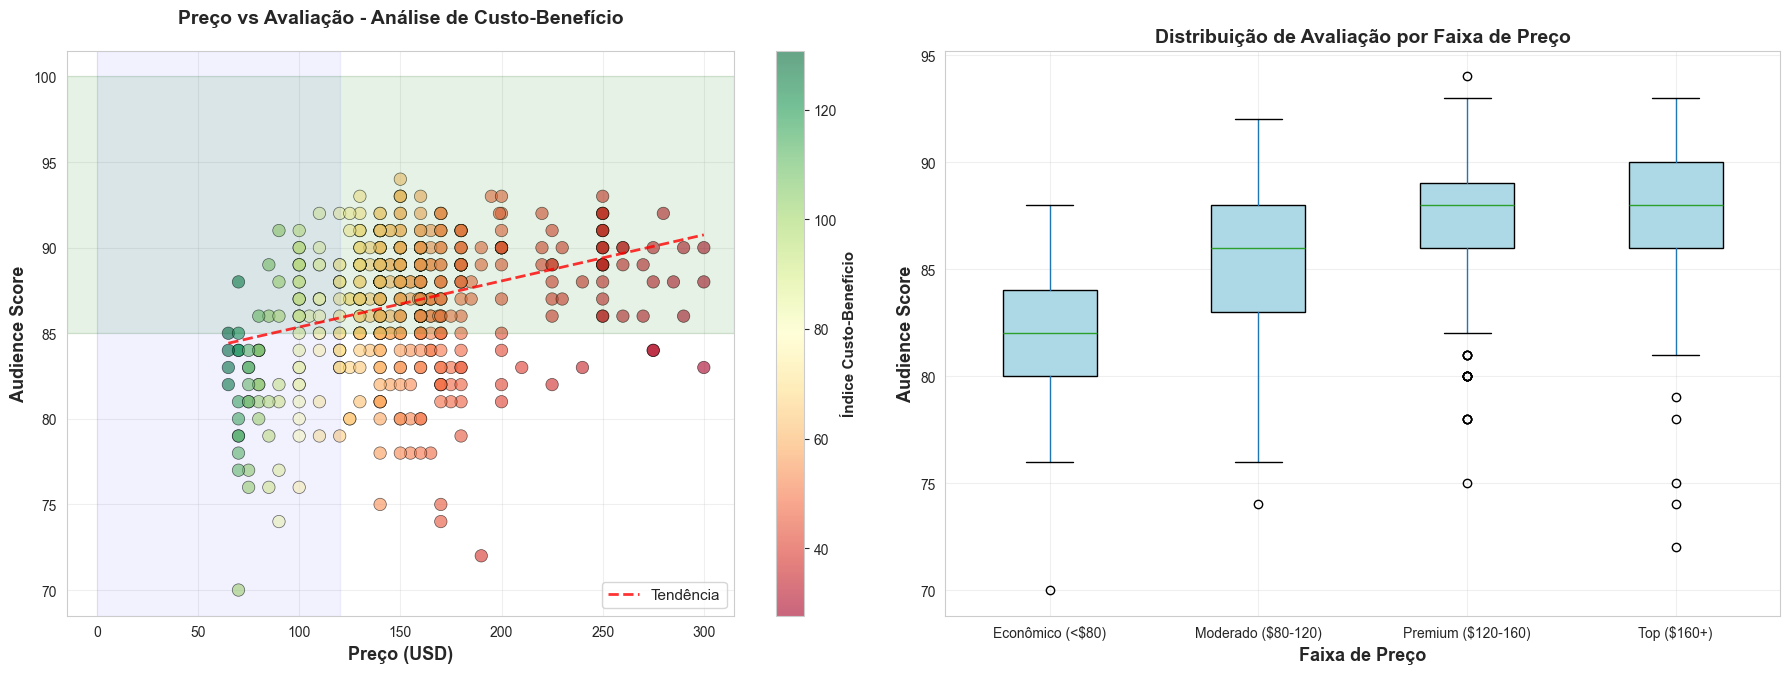


INSIGHTS:
• Correlação Preço x Avaliação: 0.315
• Tênis mais caros NEM SEMPRE têm melhor avaliação
• Existem excelentes opções em todas as faixas de preço
• A zona verde indica melhor custo-benefício (score alto + preço moderado)


In [17]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Scatter com linha de tendência
ax1 = axes[0]
scatter = ax1.scatter(df_analise['price_usd'], df_analise['audience_score'],
                     c=df_analise['custo_beneficio'], cmap='RdYlGn', 
                     s=80, alpha=0.6, edgecolors='black', linewidth=0.5)

# Linha de tendência
z = np.polyfit(df_analise['price_usd'].dropna(), 
               df_analise.loc[df_analise['price_usd'].notna(), 'audience_score'], 1)
p = np.poly1d(z)
ax1.plot(df_analise['price_usd'].sort_values(), 
         p(df_analise['price_usd'].sort_values()), 
         "r--", alpha=0.8, linewidth=2, label='Tendência')

ax1.set_xlabel('Preço (USD)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Audience Score', fontsize=13, fontweight='bold')
ax1.set_title('Preço vs Avaliação - Análise de Custo-Benefício', 
              fontsize=14, fontweight='bold', pad=20)
ax1.grid(alpha=0.3)
ax1.legend(fontsize=11)

# Adicionar zona de melhor custo-benefício (score alto, preço baixo)
ax1.axhspan(85, 100, alpha=0.1, color='green', label='Score Alto')
ax1.axvspan(0, 120, alpha=0.05, color='blue')

cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Índice Custo-Benefício', fontsize=11, fontweight='bold')

# Gráfico 2: Boxplot por faixa de preço
ax2 = axes[1]
df_analise.boxplot(column='audience_score', by='faixa_preco', ax=ax2,
                   patch_artist=True, boxprops=dict(facecolor='lightblue'))
ax2.set_xlabel('Faixa de Preço', fontsize=13, fontweight='bold')
ax2.set_ylabel('Audience Score', fontsize=13, fontweight='bold')
ax2.set_title('Distribuição de Avaliação por Faixa de Preço', 
              fontsize=14, fontweight='bold')
plt.suptitle('')  # Remove título automático do boxplot
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Calcular correlação
correlacao = df_analise[['price_usd', 'audience_score']].corr().iloc[0, 1]
print(f'\nINSIGHTS:')
print(f'• Correlação Preço x Avaliação: {correlacao:.3f}')
print('• Tênis mais caros NEM SEMPRE têm melhor avaliação')
print('• Existem excelentes opções em todas as faixas de preço')
print('• A zona verde indica melhor custo-benefício (score alto + preço moderado)')

## 6.3 Top 20 Melhores Custo-Benefício

Tênis com melhor relação entre qualidade e preço.

In [18]:
# Top 20 melhores custo-benefício
top_20_cb = df_analise.nlargest(20, 'custo_beneficio')[[
    'name', 'brand', 'price_usd', 'audience_score', 'custo_beneficio', 'pace'
]].copy()

top_20_cb.columns = ['Tênis', 'Marca', 'Preço (USD)', 'Avaliação', 
                     'Índice C/B', 'Tipo de Uso']
top_20_cb['Preço (USD)'] = top_20_cb['Preço (USD)'].apply(lambda x: f'${x:.0f}')
top_20_cb['Índice C/B'] = top_20_cb['Índice C/B'].apply(lambda x: f'{x:.2f}')
top_20_cb = top_20_cb.reset_index(drop=True)
top_20_cb.index = top_20_cb.index + 1

print(' TOP 20 MELHORES CUSTO-BENEFÍCIO')
print('='*100)
display(HTML(top_20_cb.to_html()))

print('\n OBS: Quanto maior o Índice C/B, melhor a relação qualidade/preço!')
print('ATENÇÃO: Estes tênis têm a MELHOR RELAÇÃO preço/qualidade, não necessariamente o maior score absoluto.')

 TOP 20 MELHORES CUSTO-BENEFÍCIO


,Tênis,Marca,Preço (USD),Avaliação,Índice C/B,Tipo de Uso
1,Adidas Runfalcon 5,Adidas,$65,85.0,130.77,Daily running
2,ASICS Gel Contend 7,ASICS,$65,84.0,129.23,Daily running
3,Nike Revolution 6,Nike,$65,83.0,127.69,Daily running
4,Under Armour Surge 4,Under Armour,$65,82.0,126.15,Daily running
5,ASICS Gel Venture 8,ASICS,$70,88.0,125.71,NaN
6,Nike Run Swift 2,Nike,$70,85.0,121.43,Daily running
7,ASICS Gel Contend 8,ASICS,$70,84.0,120.00,Daily running
8,Under Armour Charged Assert 9,Under Armour,$70,84.0,120.00,Daily running
9,Nike Downshifter 12,Nike,$70,81.0,115.71,Daily running
10,Nike Revolution 7,Nike,$70,80.0,114.29,Daily running



 OBS: Quanto maior o Índice C/B, melhor a relação qualidade/preço!
ATENÇÃO: Estes tênis têm a MELHOR RELAÇÃO preço/qualidade, não necessariamente o maior score absoluto.


## 6.4 Análise por Faixa de Preço - DUAS PERSPECTIVAS

### 6.4.1 Melhor Custo-Benefício por Faixa

Os tênis que oferecem a melhor relação qualidade/preço (Score/Preço).

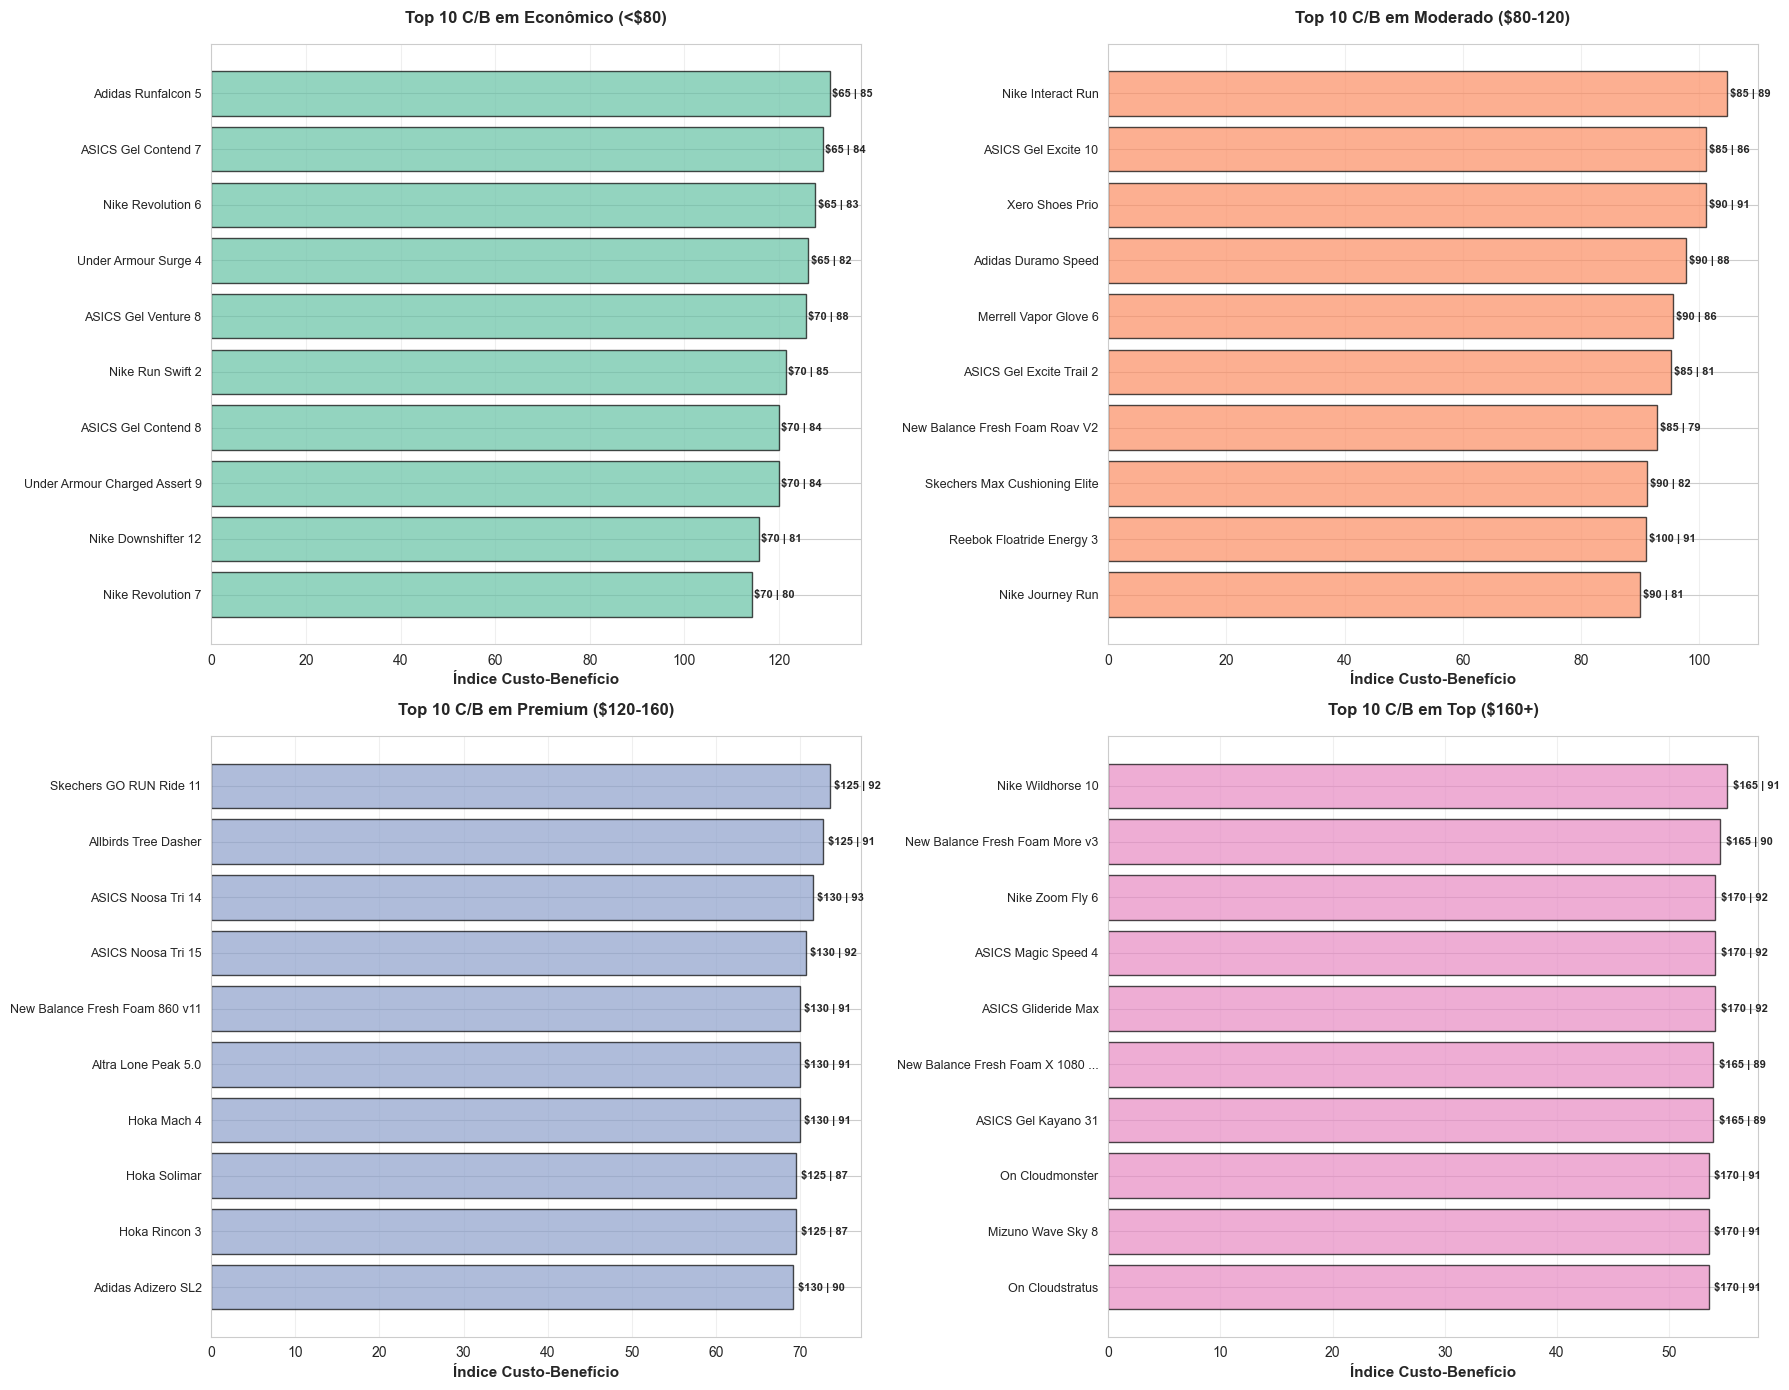


 INTERPRETAÇÃO:
• Estes são os tênis com MELHOR CUSTO-BENEFÍCIO (Score/Preço) em cada faixa
• Os valores mostram: Preço | Avaliação
• Tênis mais caros na mesma faixa terão índices menores mesmo com scores altos
•  Use para ECONOMIZAR mantendo boa qualidade!


In [19]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))
faixas = ['Econômico (<$80)', 'Moderado ($80-120)', 'Premium ($120-160)', 'Top ($160+)']
cores = ['#66c2a5', '#fc8d62', '#8da0cb', '#e78ac3']

for idx, (faixa, cor) in enumerate(zip(faixas, cores)):
    ax = axes[idx // 2, idx % 2]
    dados_faixa = df_analise[df_analise['faixa_preco'] == faixa].nlargest(10, 'custo_beneficio')
    
    # Gráfico de barras horizontais
    y_pos = np.arange(len(dados_faixa))
    bars = ax.barh(y_pos, dados_faixa['custo_beneficio'], color=cor, alpha=0.7, edgecolor='black')
    
    # Labels
    ax.set_yticks(y_pos)
    labels = [f"{name[:30]}..." if len(name) > 30 else name 
              for name in dados_faixa['name'].values]
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    
    ax.set_xlabel('Índice Custo-Benefício', fontsize=11, fontweight='bold')
    ax.set_title(f'Top 10 C/B em {faixa}', fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)
    
    # Adicionar valores nas barras
    for i, (bar, score, price) in enumerate(zip(bars, dados_faixa['audience_score'], 
                                                  dados_faixa['price_usd'])):
        width = bar.get_width()
        ax.text(width + 0.5, bar.get_y() + bar.get_height()/2, 
               f'${price:.0f} | {score:.0f}',
               ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('\n INTERPRETAÇÃO:')
print('• Estes são os tênis com MELHOR CUSTO-BENEFÍCIO (Score/Preço) em cada faixa')
print('• Os valores mostram: Preço | Avaliação')
print('• Tênis mais caros na mesma faixa terão índices menores mesmo com scores altos')
print('•  Use para ECONOMIZAR mantendo boa qualidade!')

### 6.4.2 Tênis Mais Caros de Cada Faixa

Análise dos tênis mais caros em cada faixa e suas respectivas avaliações.

In [30]:
print('TÊNIS MAIS CAROS POR FAIXA DE PREÇO')
print('='*100)
print('\nATENÇÃO: Ser mais caro NÃO garante melhor avaliação!\n')

for faixa in faixas:
    print(f'\n {faixa.upper()}')
    print('-'*100)
    
    dados_faixa = df_analise[df_analise['faixa_preco'] == faixa]
    
    if len(dados_faixa) > 0:
        # Top 10 mais caros
        mais_caros = dados_faixa.nlargest(10, 'price_usd')[[
            'name', 'brand', 'price_usd', 'audience_score', 'custo_beneficio'
        ]]
        
        print(f'\nTop 10 MAIS CAROS nesta faixa:')
        print()
        for i, (idx, row) in enumerate(mais_caros.iterrows(), 1):
            print(f"  {i:2d}. {row['name'][:42]:42} | ${row['price_usd']:6.0f} | "
              f"Score: {row['audience_score']:5.1f} | C/B: {row['custo_beneficio']:6.2f}")
        
        # Estatísticas
        print(f'\n  Análise dos 10 mais caros desta faixa:')
        print(f'     • Score médio: {mais_caros["audience_score"].mean():.1f}/100')
        print(f'     • Score máximo: {mais_caros["audience_score"].max():.0f}/100')
        print(f'     • Score mínimo: {mais_caros["audience_score"].min():.0f}/100')
        print(f'     • C/B médio: {mais_caros["custo_beneficio"].mean():.2f}')
        
        # Comparação com média da faixa
        score_medio_faixa = dados_faixa['audience_score'].mean()
        diff = mais_caros['audience_score'].mean() - score_medio_faixa
        if diff > 0:
            print(f'     • Score médio {diff:.1f} pontos ACIMA da média da faixa ({score_medio_faixa:.1f})')
        else:
            print(f'     •  Score médio {abs(diff):.1f} pontos ABAIXO da média da faixa ({score_medio_faixa:.1f})')

print('\n' + '='*100)
print('\n INSIGHT IMPORTANTE:')
print('• Nem sempre o tênis mais caro da faixa tem o melhor score')
print('• Compare o score médio dos mais caros com a média da faixa')
print('• Às vezes você paga mais por características específicas, não necessariamente qualidade geral')

TÊNIS MAIS CAROS POR FAIXA DE PREÇO

ATENÇÃO: Ser mais caro NÃO garante melhor avaliação!


 ECONÔMICO (<$80)
----------------------------------------------------------------------------------------------------

Top 10 MAIS CAROS nesta faixa:

   1. New Balance Fresh Foam 680 v8              | $    80 | Score:  84.0 | C/B: 105.00
   2. ASICS Gel Venture 10                       | $    80 | Score:  86.0 | C/B: 107.50
   3. ASICS Gel Venture 9                        | $    80 | Score:  84.0 | C/B: 105.00
   4. ASICS Versablast 4                         | $    80 | Score:  82.0 | C/B: 102.50
   5. Nike Quest 5                               | $    80 | Score:  81.0 | C/B: 101.25
   6. Adidas Ultrarun 5                          | $    80 | Score:  84.0 | C/B: 105.00
   7. Adidas Ultrabounce                         | $    80 | Score:  82.0 | C/B: 102.50
   8. Adidas Fluidflow 2.0                       | $    80 | Score:  80.0 | C/B: 100.00
   9. Under Armour Charged Assert 10             | $

### 6.4.3 Melhores Avaliações por Faixa

Agora vamos ver os tênis com MAIOR SCORE (qualidade absoluta) em cada faixa.

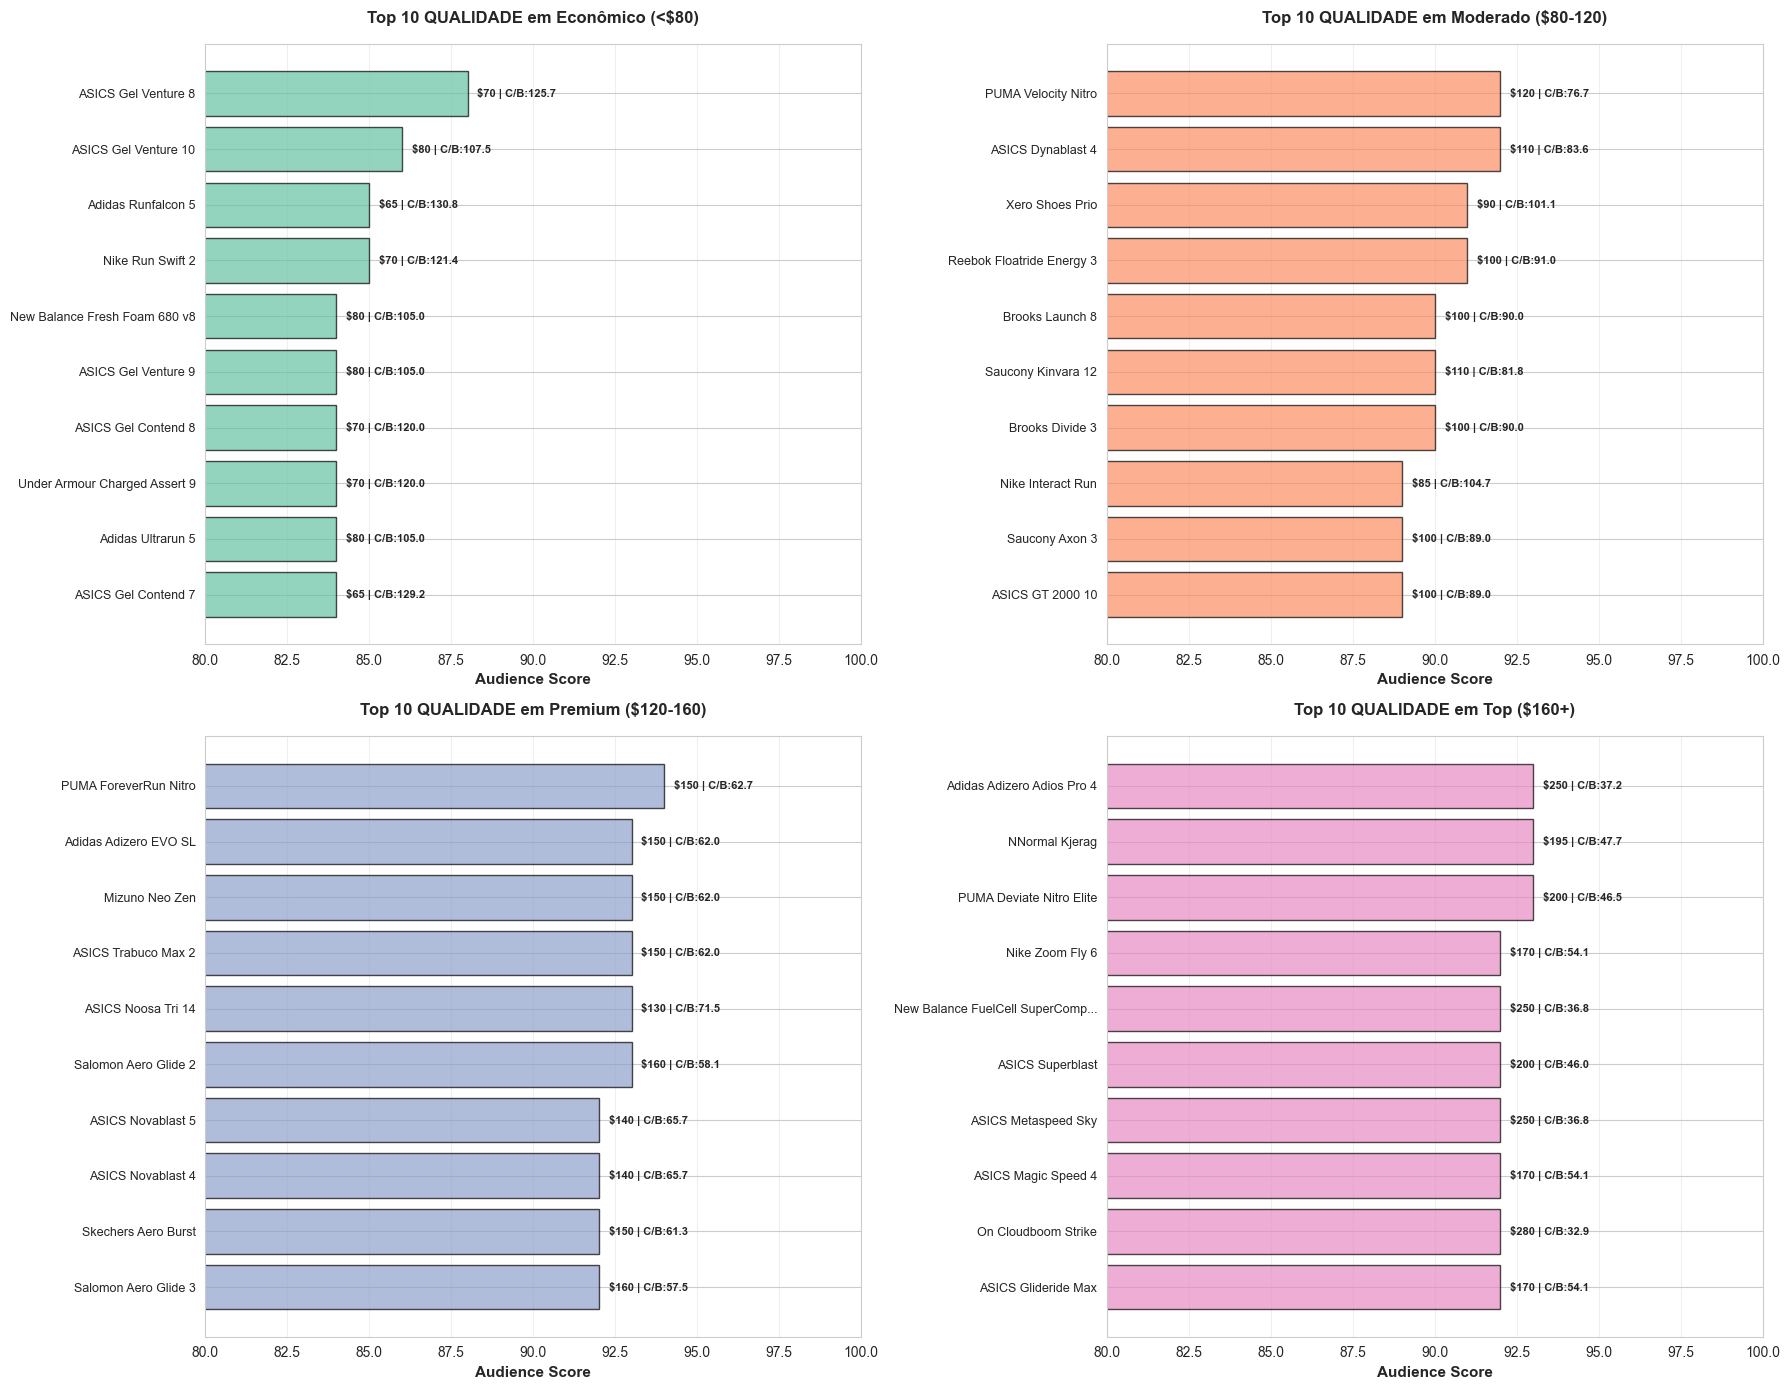


INTERPRETAÇÃO:
• Estes são os tênis com MELHOR AVALIAÇÃO (Score absoluto) em cada faixa
• Os valores mostram: Preço | Custo-Benefício
• Aqui você vê os MELHORES tênis de cada faixa independente do preço exato
• Exemplo: Adidas Adizero Adios Pro 4 ($250, Score 93) está no Top da faixa Top!
• Use para encontrar a MÁXIMA QUALIDADE dentro do seu orçamento!


In [21]:
fig, axes = plt.subplots(2, 2, figsize=(18, 14))

for idx, (faixa, cor) in enumerate(zip(faixas, cores)):
    ax = axes[idx // 2, idx % 2]
    dados_faixa = df_analise[df_analise['faixa_preco'] == faixa].nlargest(10, 'audience_score')
    
    # Gráfico de barras horizontais
    y_pos = np.arange(len(dados_faixa))
    bars = ax.barh(y_pos, dados_faixa['audience_score'], color=cor, alpha=0.7, edgecolor='black')
    
    # Labels
    ax.set_yticks(y_pos)
    labels = [f"{name[:30]}..." if len(name) > 30 else name 
              for name in dados_faixa['name'].values]
    ax.set_yticklabels(labels, fontsize=9)
    ax.invert_yaxis()
    
    ax.set_xlabel('Audience Score', fontsize=11, fontweight='bold')
    ax.set_title(f'Top 10 QUALIDADE em {faixa}', fontsize=12, fontweight='bold', pad=15)
    ax.grid(axis='x', alpha=0.3)
    ax.set_xlim([80, 100])
    
    # Adicionar valores nas barras
    for i, (bar, score, price, cb) in enumerate(zip(bars, dados_faixa['audience_score'], 
                                                      dados_faixa['price_usd'],
                                                      dados_faixa['custo_beneficio'])):
        width = bar.get_width()
        ax.text(width + 0.3, bar.get_y() + bar.get_height()/2, 
               f'${price:.0f} | C/B:{cb:.1f}',
               ha='left', va='center', fontsize=8, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nINTERPRETAÇÃO:')
print('• Estes são os tênis com MELHOR AVALIAÇÃO (Score absoluto) em cada faixa')
print('• Os valores mostram: Preço | Custo-Benefício')
print('• Aqui você vê os MELHORES tênis de cada faixa independente do preço exato')
print('• Exemplo: Adidas Adizero Adios Pro 4 ($250, Score 93) está no Top da faixa Top!')
print('• Use para encontrar a MÁXIMA QUALIDADE dentro do seu orçamento!')

## 6.5 Comparação: Custo-Benefício vs Qualidade Absoluta

Vamos criar uma tabela comparativa para entender melhor a diferença.

In [22]:
print(' COMPARAÇÃO: CUSTO-BENEFÍCIO vs QUALIDADE ABSOLUTA NA FAIXA TOP ($160+)')
print('='*100)

faixa_top = df_analise[df_analise['faixa_preco'] == 'Top ($160+)']

# Top 5 por custo-benefício
print('\nTOP 5 CUSTO-BENEFÍCIO (melhor relação preço/qualidade):')
print('-'*100)
top_cb = faixa_top.nlargest(5, 'custo_beneficio')[['name', 'price_usd', 'audience_score', 'custo_beneficio']]
for i, (idx, row) in enumerate(top_cb.iterrows(), 1):
    print(f"{i}. {row['name'][:45]:45} | ${row['price_usd']:6.0f} | Score: {row['audience_score']:5.1f} | C/B: {row['custo_beneficio']:6.2f}")

# Top 5 por score
print('\nTOP 5 QUALIDADE (maior avaliação absoluta):')
print('-'*100)
top_score = faixa_top.nlargest(5, 'audience_score')[['name', 'price_usd', 'audience_score', 'custo_beneficio']]
for i, (idx, row) in enumerate(top_score.iterrows(), 1):
    print(f"{i}. {row['name'][:45]:45} | ${row['price_usd']:6.0f} | Score: {row['audience_score']:5.1f} | C/B: {row['custo_beneficio']:6.2f}")

print('\n' + '='*100)
print('\n OBSERVAÇÃO IMPORTANTE:')
print('• Os tênis com melhor CUSTO-BENEFÍCIO são mais baratos dentro da faixa (~$160-170)')
print('• Os tênis com melhor QUALIDADE podem custar mais (~$200-280) mas têm scores máximos')
print('• Ambas as perspectivas são válidas, dependendo do seu objetivo:')
print('  - Economizar? → Veja custo-benefício')
print('  - Máxima performance? → Veja qualidade absoluta')

 COMPARAÇÃO: CUSTO-BENEFÍCIO vs QUALIDADE ABSOLUTA NA FAIXA TOP ($160+)

TOP 5 CUSTO-BENEFÍCIO (melhor relação preço/qualidade):
----------------------------------------------------------------------------------------------------
1. Nike Wildhorse 10                             | $   165 | Score:  91.0 | C/B:  55.15
2. New Balance Fresh Foam More v3                | $   165 | Score:  90.0 | C/B:  54.55
3. Nike Zoom Fly 6                               | $   170 | Score:  92.0 | C/B:  54.12
4. ASICS Magic Speed 4                           | $   170 | Score:  92.0 | C/B:  54.12
5. ASICS Glideride Max                           | $   170 | Score:  92.0 | C/B:  54.12

TOP 5 QUALIDADE (maior avaliação absoluta):
----------------------------------------------------------------------------------------------------
1. Adidas Adizero Adios Pro 4                    | $   250 | Score:  93.0 | C/B:  37.20
2. NNormal Kjerag                                | $   195 | Score:  93.0 | C/B:  47.69
3. PUMA 

## 6.6 Melhores Opções por Categoria de Score e Preço

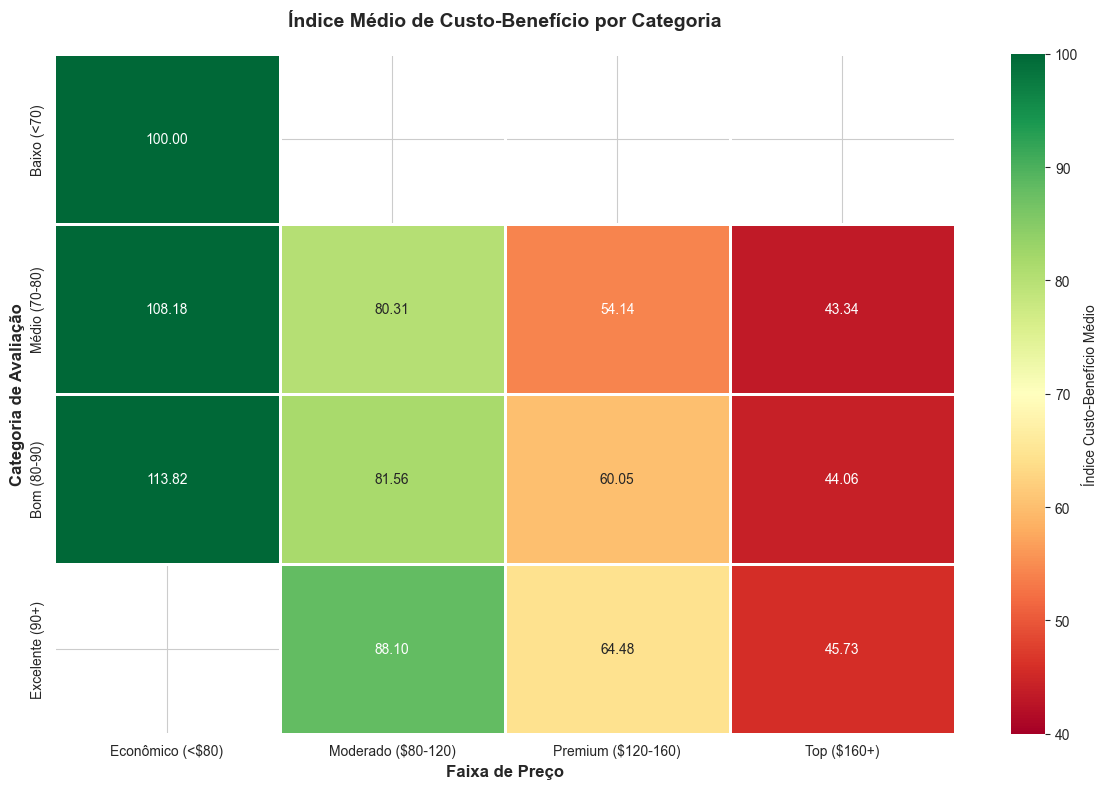


 INSIGHT: Valores mais altos (verde) = melhor custo-benefício
 Tênis econômicos com boas avaliações têm os melhores índices!


In [23]:
# Tabela cruzada
tabela_cruzada = pd.crosstab(df_analise['categoria_score'], 
                             df_analise['faixa_preco'], 
                             values=df_analise['custo_beneficio'],
                             aggfunc='mean').round(2)

# Visualização em heatmap
plt.figure(figsize=(12, 8))
sns.heatmap(tabela_cruzada, annot=True, fmt='.2f', cmap='RdYlGn', 
            cbar_kws={'label': 'Índice Custo-Benefício Médio'},
            linewidths=2, linecolor='white', vmin=40, vmax=100)
plt.title('Índice Médio de Custo-Benefício por Categoria', 
          fontsize=14, fontweight='bold', pad=20)
plt.xlabel('Faixa de Preço', fontsize=12, fontweight='bold')
plt.ylabel('Categoria de Avaliação', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.show()

print('\n INSIGHT: Valores mais altos (verde) = melhor custo-benefício')
print(' Tênis econômicos com boas avaliações têm os melhores índices!')

## 6.7 Análise de Durabilidade vs Preço

Avaliando se tênis mais caros são mais duráveis.

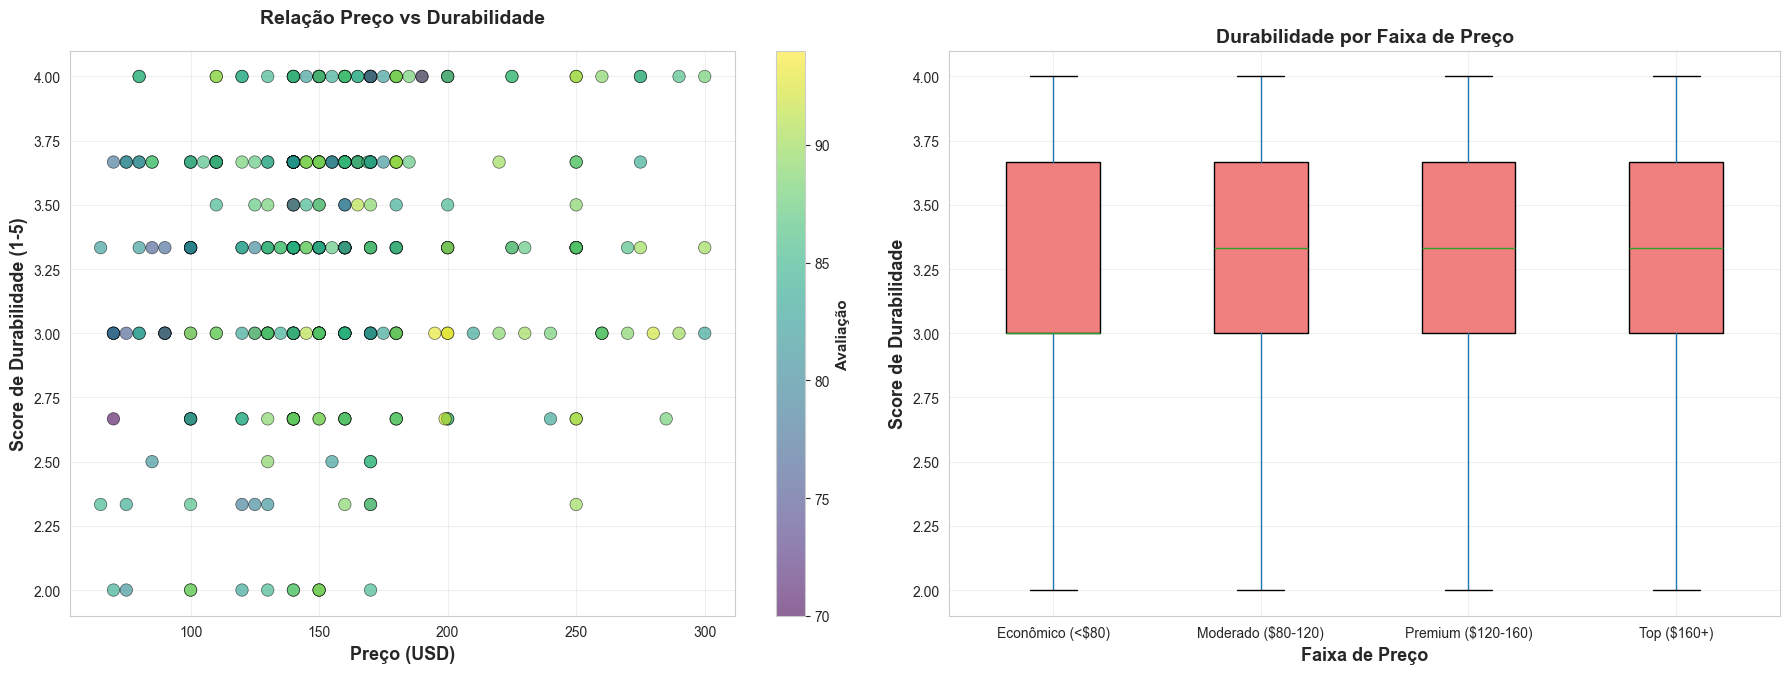


Correlação Preço x Durabilidade: 0.125
INSIGHT: A durabilidade tem BAIXA correlação com o preço!
Existem tênis baratos e duráveis, e caros com durabilidade média.


In [24]:
# Preparar dados de durabilidade
durabilidade_cols = ['toebox durability', 'heel padding durability', 'outsole durability']
df_durabilidade = df_analise[df_analise[durabilidade_cols].notna().any(axis=1)].copy()

# Criar score de durabilidade
durabilidade_map = {'Excellent': 5, 'Good': 4, 'Decent': 3, 'Bad': 2}

for col in durabilidade_cols:
    df_durabilidade[f'{col}_score'] = df_durabilidade[col].map(durabilidade_map)

df_durabilidade['durabilidade_media'] = df_durabilidade[
    [f'{col}_score' for col in durabilidade_cols]
].mean(axis=1)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Scatter: Preço vs Durabilidade
ax1 = axes[0]
scatter = ax1.scatter(df_durabilidade['price_usd'], 
                     df_durabilidade['durabilidade_media'],
                     c=df_durabilidade['audience_score'], 
                     cmap='viridis', s=80, alpha=0.6, 
                     edgecolors='black', linewidth=0.5)
ax1.set_xlabel('Preço (USD)', fontsize=13, fontweight='bold')
ax1.set_ylabel('Score de Durabilidade (1-5)', fontsize=13, fontweight='bold')
ax1.set_title('Relação Preço vs Durabilidade', fontsize=14, fontweight='bold', pad=20)
ax1.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Avaliação', fontsize=11, fontweight='bold')

# Boxplot: Durabilidade por faixa de preço
ax2 = axes[1]
df_durabilidade.boxplot(column='durabilidade_media', by='faixa_preco', ax=ax2,
                        patch_artist=True, boxprops=dict(facecolor='lightcoral'))
ax2.set_xlabel('Faixa de Preço', fontsize=13, fontweight='bold')
ax2.set_ylabel('Score de Durabilidade', fontsize=13, fontweight='bold')
ax2.set_title('Durabilidade por Faixa de Preço', fontsize=14, fontweight='bold')
plt.suptitle('')
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Correlação
corr_dur_preco = df_durabilidade[['price_usd', 'durabilidade_media']].corr().iloc[0, 1]
print(f'\nCorrelação Preço x Durabilidade: {corr_dur_preco:.3f}')
print('INSIGHT: A durabilidade tem BAIXA correlação com o preço!')
print('Existem tênis baratos e duráveis, e caros com durabilidade média.')

## 6.8 Recomendações por Perfil de Corredor

Melhores opções de custo-benefício por tipo de uso.

In [25]:
# Analisar por tipo de uso (pace)
df_pace = df_analise[df_analise['pace'].notna()].copy()

# Principais tipos de uso
tipos_uso = ['Daily running', 'Tempo', 'Racing', 'Trail running']

print('RECOMENDAÇÕES POR PERFIL DE CORREDOR (Melhor Custo-Benefício)')
print('='*100)

for tipo in tipos_uso:
    # Filtrar tênis que incluem esse tipo
    df_tipo = df_pace[df_pace['pace'].str.contains(tipo, case=False, na=False)]
    
    if len(df_tipo) > 0:
        top_5 = df_tipo.nlargest(5, 'custo_beneficio')[[
            'name', 'brand', 'price_usd', 'audience_score', 'custo_beneficio'
        ]].copy()
        
        print(f'\n{tipo.upper()}')
        print('-'*100)
        
        for idx, row in top_5.iterrows():
            print(f"  {row['name'][:40]:40} | {row['brand']:15} | ${row['price_usd']:6.0f} | "
                  f"Score: {row['audience_score']:5.1f} | C/B: {row['custo_beneficio']:6.2f}")

print('\n' + '='*100)

RECOMENDAÇÕES POR PERFIL DE CORREDOR (Melhor Custo-Benefício)

DAILY RUNNING
----------------------------------------------------------------------------------------------------
  Adidas Runfalcon 5                       | Adidas          | $    65 | Score:  85.0 | C/B: 130.77
  ASICS Gel Contend 7                      | ASICS           | $    65 | Score:  84.0 | C/B: 129.23
  Nike Revolution 6                        | Nike            | $    65 | Score:  83.0 | C/B: 127.69
  Under Armour Surge 4                     | Under Armour    | $    65 | Score:  82.0 | C/B: 126.15
  Nike Run Swift 2                         | Nike            | $    70 | Score:  85.0 | C/B: 121.43

TEMPO
----------------------------------------------------------------------------------------------------
  Brooks Launch 8                          | Brooks          | $   100 | Score:  90.0 | C/B:  90.00
  Saucony Axon 3                           | Saucony         | $   100 | Score:  89.0 | C/B:  89.00
  Saucony Axon

## 6.9 Análise de Marcas - Custo-Benefício Médio

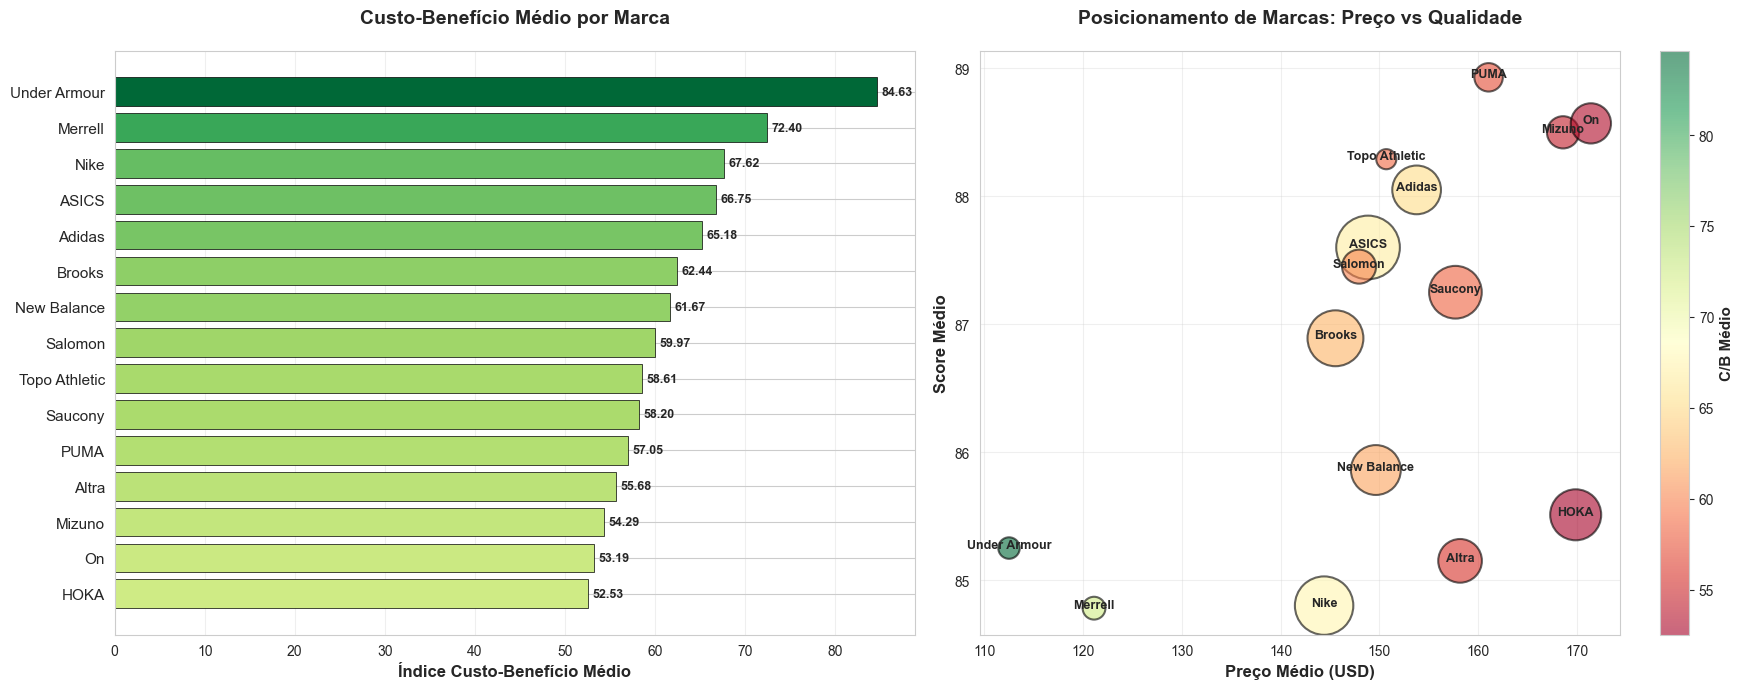


RANKING DE MARCAS POR CUSTO-BENEFÍCIO


,C/B Médio,Preço Médio,Score Médio,Qtd Modelos
brand,,,,
Under Armour,84.63,112.50,85.25,8
Merrell,72.40,121.11,84.78,9
Nike,67.62,144.41,84.80,59
ASICS,66.75,148.86,87.60,70
Adidas,65.18,153.78,88.05,41
Brooks,62.44,145.56,86.89,54
New Balance,61.67,149.65,85.86,43
Salomon,59.97,147.95,87.45,20
Topo Athletic,58.61,150.71,88.29,7



 O tamanho das bolhas representa a quantidade de modelos disponíveis


In [26]:
# Análise por marca (apenas marcas com 5+ tênis)
marcas_contagem = df_analise['brand'].value_counts()
marcas_principais = marcas_contagem[marcas_contagem >= 5].index

df_marcas = df_analise[df_analise['brand'].isin(marcas_principais)].copy()

# Agregar por marca
marcas_stats = df_marcas.groupby('brand').agg({
    'custo_beneficio': 'mean',
    'price_usd': 'mean',
    'audience_score': 'mean',
    'name': 'count'
}).round(2)

marcas_stats.columns = ['C/B Médio', 'Preço Médio', 'Score Médio', 'Qtd Modelos']
marcas_stats = marcas_stats.sort_values('C/B Médio', ascending=False)

# Visualização
fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# Gráfico 1: Custo-benefício por marca
ax1 = axes[0]
y_pos = np.arange(len(marcas_stats))
bars = ax1.barh(y_pos, marcas_stats['C/B Médio'], 
                color=plt.cm.RdYlGn(marcas_stats['C/B Médio']/marcas_stats['C/B Médio'].max()),
                edgecolor='black', linewidth=0.5)
ax1.set_yticks(y_pos)
ax1.set_yticklabels(marcas_stats.index, fontsize=11)
ax1.invert_yaxis()
ax1.set_xlabel('Índice Custo-Benefício Médio', fontsize=12, fontweight='bold')
ax1.set_title('Custo-Benefício Médio por Marca', fontsize=14, fontweight='bold', pad=20)
ax1.grid(axis='x', alpha=0.3)

# Adicionar valores
for i, (bar, val) in enumerate(zip(bars, marcas_stats['C/B Médio'])):
    ax1.text(val + 0.5, bar.get_y() + bar.get_height()/2, 
            f'{val:.2f}', ha='left', va='center', fontweight='bold', fontsize=9)

# Gráfico 2: Score vs Preço por marca
ax2 = axes[1]
scatter = ax2.scatter(marcas_stats['Preço Médio'], marcas_stats['Score Médio'],
                     s=marcas_stats['Qtd Modelos']*30, 
                     c=marcas_stats['C/B Médio'], cmap='RdYlGn',
                     alpha=0.6, edgecolors='black', linewidth=1.5)

# Adicionar labels das marcas
for marca, row in marcas_stats.iterrows():
    ax2.annotate(marca, (row['Preço Médio'], row['Score Médio']),
                fontsize=9, ha='center', fontweight='bold')

ax2.set_xlabel('Preço Médio (USD)', fontsize=12, fontweight='bold')
ax2.set_ylabel('Score Médio', fontsize=12, fontweight='bold')
ax2.set_title('Posicionamento de Marcas: Preço vs Qualidade', 
              fontsize=14, fontweight='bold', pad=20)
ax2.grid(alpha=0.3)
cbar = plt.colorbar(scatter, ax=ax2)
cbar.set_label('C/B Médio', fontsize=11, fontweight='bold')

plt.tight_layout()
plt.show()

print('\nRANKING DE MARCAS POR CUSTO-BENEFÍCIO')
print('='*80)
display(HTML(marcas_stats.to_html()))
print('\n O tamanho das bolhas representa a quantidade de modelos disponíveis')

## 6.10 Matriz de Decisão: Guia de Compra

In [27]:
print('GUIA DE COMPRA - COMO ESCOLHER O MELHOR TÊNIS')
print('='*100)
print()

# Criar matriz de decisão
orcamentos = [
    ('Econômico (até $80)', 'Econômico (<$80)'),
    ('Moderado ($80-120)', 'Moderado ($80-120)'),
    ('Premium ($120-160)', 'Premium ($120-160)'),
    ('Top ($160+)', 'Top ($160+)')
]

for nome_orcamento, faixa in orcamentos:
    print(f'\n{nome_orcamento}')
    print('-'*100)
    
    df_orcamento = df_analise[df_analise['faixa_preco'] == faixa]
    
    if len(df_orcamento) > 0:
        # Top 3 melhores custo-benefício
        top_3_cb = df_orcamento.nlargest(3, 'custo_beneficio')
        
        print('\nTOP 3 CUSTO-BENEFÍCIO (Economize!):')
        for i, (idx, row) in enumerate(top_3_cb.iterrows(), 1):
            print(f'\n  {i}. {row["name"]}')
            print(f'     Marca: {row["brand"]} | Preço: ${row["price_usd"]:.0f} | '
                  f'Avaliação: {row["audience_score"]:.0f}/100')
            print(f'     Índice C/B: {row["custo_beneficio"]:.2f} | Uso: {row["pace"]}')
        
        # Top 3 melhores scores
        top_3_score = df_orcamento.nlargest(3, 'audience_score')
        
        print('\nTOP 3 QUALIDADE (Máxima Performance!):')
        for i, (idx, row) in enumerate(top_3_score.iterrows(), 1):
            print(f'\n  {i}. {row["name"]}')
            print(f'     Marca: {row["brand"]} | Preço: ${row["price_usd"]:.0f} | '
                  f'Avaliação: {row["audience_score"]:.0f}/100')
            print(f'     Índice C/B: {row["custo_beneficio"]:.2f} | Uso: {row["pace"]}')
        
        # Estatísticas da faixa
        print(f'\n Estatísticas desta faixa:')
        print(f'     • {len(df_orcamento)} modelos disponíveis')
        print(f'     • Preço médio: ${df_orcamento["price_usd"].mean():.2f}')
        print(f'     • Score médio: {df_orcamento["audience_score"].mean():.1f}/100')
        print(f'     • C/B médio: {df_orcamento["custo_beneficio"].mean():.2f}')

print('\n' + '='*100)
print('\nCONCLUSÃO:')
print('   • Não é necessário gastar muito para ter um bom tênis!')
print('   • Escolha entre ECONOMIZAR (C/B) ou MÁXIMA PERFORMANCE (Score)')
print('   • Priorize o tipo de uso adequado ao seu perfil')
print('   • Considere também durabilidade, peso e conforto para sua decisão final')

GUIA DE COMPRA - COMO ESCOLHER O MELHOR TÊNIS


Econômico (até $80)
----------------------------------------------------------------------------------------------------

TOP 3 CUSTO-BENEFÍCIO (Economize!):

  1. Adidas Runfalcon 5
     Marca: Adidas | Preço: $65 | Avaliação: 85/100
     Índice C/B: 130.77 | Uso: Daily running

  2. ASICS Gel Contend 7
     Marca: ASICS | Preço: $65 | Avaliação: 84/100
     Índice C/B: 129.23 | Uso: Daily running

  3. Nike Revolution 6
     Marca: Nike | Preço: $65 | Avaliação: 83/100
     Índice C/B: 127.69 | Uso: Daily running

TOP 3 QUALIDADE (Máxima Performance!):

  1. ASICS Gel Venture 8
     Marca: ASICS | Preço: $70 | Avaliação: 88/100
     Índice C/B: 125.71 | Uso: nan

  2. ASICS Gel Venture 10
     Marca: ASICS | Preço: $80 | Avaliação: 86/100
     Índice C/B: 107.50 | Uso: nan

  3. Adidas Runfalcon 5
     Marca: Adidas | Preço: $65 | Avaliação: 85/100
     Índice C/B: 130.77 | Uso: Daily running

 Estatísticas desta faixa:
     • 31 modelo

## 6.11 Resumo Executivo

In [28]:
# Gerar estatísticas finais
melhor_cb_geral = df_analise.nlargest(1, 'custo_beneficio').iloc[0]
melhor_score = df_analise.nlargest(1, 'audience_score').iloc[0]
mais_caro = df_analise.nlargest(1, 'price_usd').iloc[0]
mais_barato = df_analise.nsmallest(1, 'price_usd').iloc[0]

print('RESUMO EXECUTIVO - ANÁLISE DE CUSTO-BENEFÍCIO')
print('='*100)
print()

print(' DESTAQUES:')
print(f'\n  Melhor Custo-Benefício Geral:')
print(f'  • {melhor_cb_geral["name"]}')
print(f'  • Preço: ${melhor_cb_geral["price_usd"]:.0f} | Score: {melhor_cb_geral["audience_score"]:.0f}/100')
print(f'  • Índice C/B: {melhor_cb_geral["custo_beneficio"]:.2f}')

print(f'\n  Melhor Avaliação:')
print(f'  • {melhor_score["name"]}')
print(f'  • Preço: ${melhor_score["price_usd"]:.0f} | Score: {melhor_score["audience_score"]:.0f}/100')

print(f'\n  Opção Mais Econômica:')
print(f'  • {mais_barato["name"]}')
print(f'  • Preço: ${mais_barato["price_usd"]:.0f} | Score: {mais_barato["audience_score"]:.0f}/100')

print(f'\n  Mais Caro:')
print(f'  • {mais_caro["name"]}')
print(f'  • Preço: ${mais_caro["price_usd"]:.0f} | Score: {mais_caro["audience_score"]:.0f}/100')

print('\n\n ESTATÍSTICAS GERAIS:')
print(f'  • Total de tênis analisados: {len(df_analise)}')
print(f'  • Preço médio: ${df_analise["price_usd"].mean():.2f}')
print(f'  • Score médio: {df_analise["audience_score"].mean():.1f}/100')
print(f'  • Índice C/B médio: {df_analise["custo_beneficio"].mean():.2f}')
print(f'  • Faixa de preço: ${df_analise["price_usd"].min():.0f} - ${df_analise["price_usd"].max():.0f}')

print('\n\n PRINCIPAIS INSIGHTS:')
print('  1. Correlação preço x qualidade é BAIXA - não precisa ser caro para ser bom')
print('  2. Faixa econômica (<$80) tem excelentes opções com ótimo custo-benefício')
print('  3. Durabilidade não depende diretamente do preço')
print('  4. Todas as faixas de preço têm tênis bem avaliados (85+)')
print('  5. O tipo de uso (daily, tempo, racing) é mais importante que o preço')
print('  6. Tênis caros têm scores altos, mas C/B menor (menos "valor por dólar")')

print('\n\n COMO INTERPRETAR OS RESULTADOS:')
print('  • CUSTO-BENEFÍCIO: Use quando quer economizar mantendo qualidade')
print('  • QUALIDADE ABSOLUTA: Use quando quer a máxima performance')
print('  • Ambas perspectivas são válidas e complementares!')

print('\n\nRECOMENDAÇÃO FINAL:')
print('  • Defina seu orçamento e tipo de uso primeiro')
print('  • Decida: economizar (C/B) ou máxima performance (Score)?')
print('  • Use as tabelas específicas da sua faixa de preço')
print('  • Não pague mais esperando proporcionalmente mais qualidade')
print('  • Um tênis de $170 pode ser tão bom quanto um de $250!')
print('\n' + '='*100)

RESUMO EXECUTIVO - ANÁLISE DE CUSTO-BENEFÍCIO

 DESTAQUES:

  Melhor Custo-Benefício Geral:
  • Adidas Runfalcon 5
  • Preço: $65 | Score: 85/100
  • Índice C/B: 130.77

  Melhor Avaliação:
  • PUMA ForeverRun Nitro
  • Preço: $150 | Score: 94/100

  Opção Mais Econômica:
  • Adidas Runfalcon 5
  • Preço: $65 | Score: 85/100

  Mais Caro:
  • Adidas Adizero Prime X 2 Strung
  • Preço: $300 | Score: 88/100


 ESTATÍSTICAS GERAIS:
  • Total de tênis analisados: 521
  • Preço médio: $152.70
  • Score médio: 86.8/100
  • Índice C/B médio: 61.59
  • Faixa de preço: $65 - $300


 PRINCIPAIS INSIGHTS:
  1. Correlação preço x qualidade é BAIXA - não precisa ser caro para ser bom
  2. Faixa econômica (<$80) tem excelentes opções com ótimo custo-benefício
  3. Durabilidade não depende diretamente do preço
  4. Todas as faixas de preço têm tênis bem avaliados (85+)
  5. O tipo de uso (daily, tempo, racing) é mais importante que o preço
  6. Tênis caros têm scores altos, mas C/B menor (menos "valo